# Pretraining Analysis — ARCADE + MedVAE

Ce notebook compare trois versions de l'encodeur MedVAE sur le dataset ARCADE (angiographies coronariennes) afin d'évaluer la qualité des représentations apprises à chaque étape d'entraînement.

| Modèle | Entraînement | Objectif |
|--------|-------------|----------|
| **original** | Pré-entraîné sur données médicales génériques (Stanford / HuggingFace) | Reconstruction généraliste |
| **stage1** | Fine-tuné sur ARCADE (VAE classique) | Reconstruction sur le domaine cible |
| **stage2** | Entraîné avec JEPA self-supervised sur ARCADE | Représentations discriminantes sans labels |

**Question centrale** : est-ce que les représentations apprises permettent de distinguer les structures vasculaires du fond, sans supervision explicite ?

L'analyse progresse du plus simple au plus interprétatif : structure du dataset → qualité de reconstruction → structure de l'espace latent → interprétation visuelle des features.

In [16]:
import sys
import torch
import matplotlib.pyplot as plt

ROOT = "/home/infres/yrothlin-24/projet_IM06"
sys.path.insert(0, ROOT)
sys.path.insert(0, f"{ROOT}/jepa_adaptation")

from utils.launch import bootstrap, load_config, count_parameters
bootstrap()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 1. Dataset ARCADE


train : 1350 images
val   : 150 images
shape : (1, 512, 512)  dtype=torch.float32
min=-1.000  max=1.000  (attendu [-1, 1])


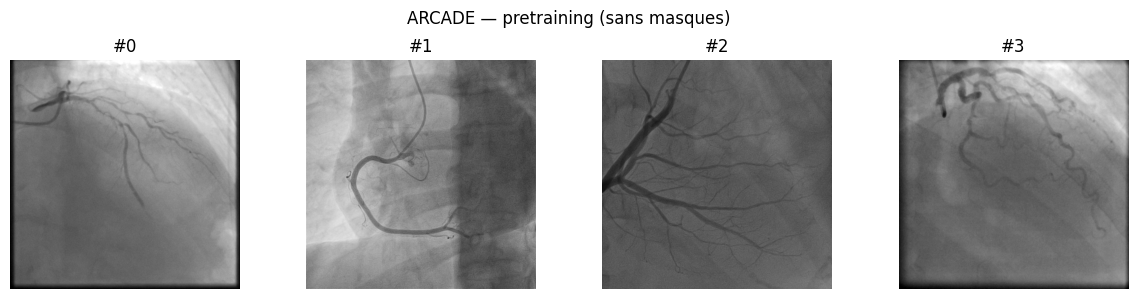

In [17]:
from datasets.arcade_dataset import get_pretraining_datasets
from torch.utils.data import DataLoader

IMG_SIZE = 512

train_ds, val_ds = get_pretraining_datasets(img_size=IMG_SIZE, val_ratio=0.1, augment=False)

print(f"train : {len(train_ds)} images")
print(f"val   : {len(val_ds)} images")

sample = train_ds[0]
print(f"shape : {tuple(sample.shape)}  dtype={sample.dtype}")
print(f"min={sample.min():.3f}  max={sample.max():.3f}  (attendu [-1, 1])")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, i in zip(axes, range(4)):
    ax.imshow(train_ds[i][0], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
    ax.set_title(f"#{i}")
plt.suptitle("ARCADE — pretraining (sans masques)")
plt.tight_layout()
plt.show()

probe_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

## 2. MedVAE — chargement des trois modèles


In [18]:
from models.medvae import MVAE

def load_medvae(source: str) -> MVAE:
    """Renvoie un MVAE chargé depuis les poids originaux, stage 1 ou stage 2."""
    if source == "original":
        ddconfig = dict(
            double_z=True, z_channels=1, resolution=512, in_channels=1, out_ch=1,
            ch=128, ch_mult=[1, 2, 4], num_res_blocks=2, attn_resolutions=[], dropout=0.0,
        )
        return MVAE(
            ddconfig=ddconfig, embed_dim=1, spatial_dims=2,
            apply_channel_ds=False, medvae_pretrained="medvae_4_1_2d",
        )

    cfg = load_config(
        f"{ROOT}/jepa_adaptation/configs/stage_2.yaml",
        f"{ROOT}/jepa_adaptation/configs/model.yaml",
    )
    mc = cfg["model"]
    mvae = MVAE(
        ddconfig=mc["ddconfig"],
        embed_dim=int(mc["embed_dim"]),
        spatial_dims=2,
        apply_channel_ds=bool(mc["apply_channel_ds"]),
    )

    if source == "stage1":
        mvae.load_weights(f"{ROOT}/jepa_adaptation/outputs/stage1/best.pt")
    elif source == "stage2":
        ckpt   = torch.load(f"{ROOT}/jepa_adaptation/outputs/stage2/best.pt", map_location="cpu")["model"]
        prefix = "context_encoder.autoencoder."
        state  = {k[len(prefix):]: v for k, v in ckpt.items() if k.startswith(prefix)}
        result = mvae.model.load_state_dict(state, strict=False)
        print(f"[stage2] {len(state)} clés extraites | missing={len(result.missing_keys)} | unexpected={len(result.unexpected_keys)}")
        if result.missing_keys:
            print(f"  missing (5 premiers): {result.missing_keys[:5]}")
    else:
        raise ValueError(f"source inconnu : {source!r}")

    return mvae


def encode_repr(ae, x):
    """Retourne le latent de représentation :
    - stage1/2 : channel_proj(channel_ds(z) + z)  ← tête JEPA, diffère entre stages
    - original  : z                                 ← apply_channel_ds=False
    NE PAS utiliser pour la reconstruction (toujours ae.encode().mode() + ae.decode()).
    """
    z, _, latent = ae.compute_latent_proj(x, sample_posterior=False)
    return latent if latent is not None else z

## 3. Comparaison structurelle des modèles


In [19]:
import pandas as pd

SOURCES = ["original", "stage1", "stage2"]
x_batch = next(iter(probe_loader)).to(device)

rows = []
autoencoders = {}
for source in SOURCES:
    print(f"\n--- {source} ---")
    mvae = load_medvae(source)
    ae   = mvae.model.to(device).eval()
    autoencoders[source] = ae

    total, _ = count_parameters(ae)
    enc, _   = count_parameters(ae.encoder)
    dec, _   = count_parameters(ae.decoder)

    with torch.no_grad():
        z_recon                = ae.encode(x_batch).mode()
        z_repr                 = encode_repr(ae, x_batch)

    h, zh = x_batch.shape[-2], z_recon.shape[-2]

    rows.append({
        "source":          source,
        "total (M)":       round(total / 1e6, 2),
        "encoder (M)":     round(enc   / 1e6, 2),
        "decoder (M)":     round(dec   / 1e6, 2),
        "recon latent":    f"{tuple(z_recon.shape[1:])}",
        "repr latent":     f"{tuple(z_repr.shape[1:])}",
        "compression":     f"{h // zh}×",
        "repr std":        round(float(z_repr.std()), 3),
    })

df = pd.DataFrame(rows).set_index("source")
df


--- original ---
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 1, 128, 128) = 16384 dimensions.
making attention of type 'vanilla' with 512 in_channels
[MVAE] loaded /home/infres/yrothlin-24/.cache/huggingface/hub/models--stanfordmimi--MedVAE/snapshots/8040c5ccb7a51eff6b4cef513c7f20bd1bda983d/model_weights/vae_4x_1c_2D.ckpt (0 missing, 8 unexpected)
[MVAE] unexpected keys:
    channel_ds.0.weight
    channel_ds.0.bias
    channel_ds.2.weight
    channel_ds.2.bias
    channel_ds.4.weight
    channel_ds.4.bias
    channel_proj.weight
    channel_proj.bias

--- stage1 ---
making attention of type 'vanilla' with 256 in_channels
Working with z of shape (1, 1, 64, 64) = 4096 dimensions.
making attention of type 'vanilla' with 256 in_channels
[MVAE] loaded /home/infres/yrothlin-24/projet_IM06/jepa_adaptation/outputs/stage1/best.pt (0 missing, 0 unexpected)

--- stage2 ---
making attention of type 'vanilla' with 256 in_channels
Working with z of shape (1,

,total (M),encoder (M),decoder (M),recon latent,repr latent,compression,repr std
source,,,,,,,
original,55.28,22.33,32.95,"(1, 128, 128)","(1, 128, 128)",4×,8.150
stage1,20.96,8.54,12.38,"(1, 64, 64)","(1, 64, 64)",8×,2.293
stage2,20.96,8.54,12.38,"(1, 64, 64)","(1, 64, 64)",8×,1.588


## 4. Reconstruction visuelle sur une image ARCADE


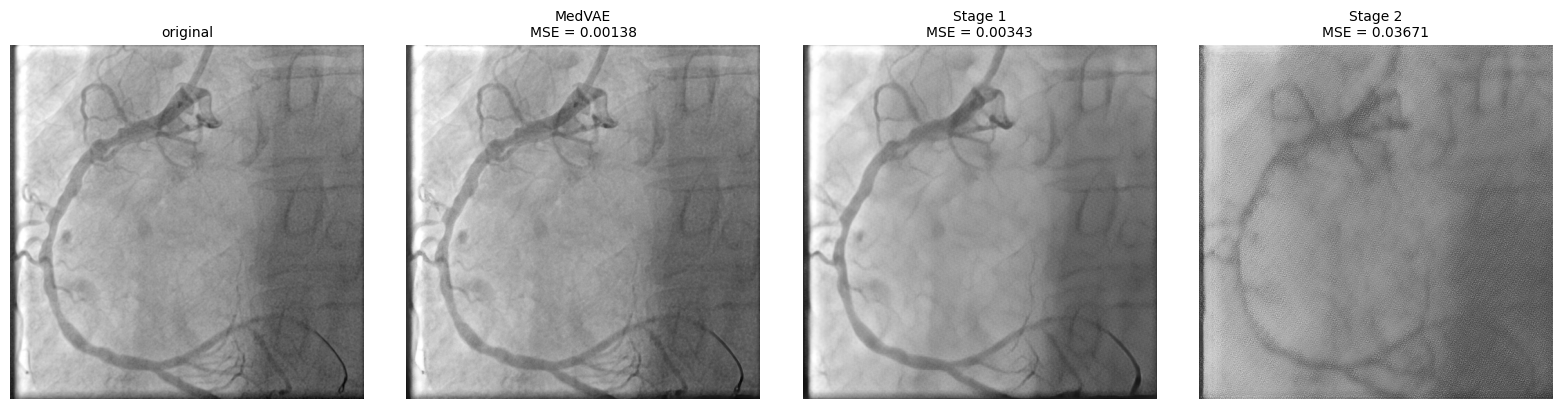

In [34]:
IMG_IDX = 0
SOURCES = ["original", "stage1", "stage2"]

x = val_ds[IMG_IDX].unsqueeze(0).to(device)

recons = {}
for source in SOURCES:
    ae = autoencoders[source]
    with torch.no_grad():
        z     = ae.encode(x).mode()
        recon = ae.decode(z)
    recons[source] = recon.squeeze().cpu().clamp(-1, 1)

x_np = x.squeeze().cpu().numpy()
x_t  = torch.tensor(x_np)
mses = {s: float(((recons[s] - x_t) ** 2).mean()) for s in SOURCES}

LABELS = {"original": "MedVAE", "stage1": "Stage 1", "stage2": "Stage 2"}

ncols = 1 + len(SOURCES)
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 4))

axes[0].imshow(x_np, cmap="gray", vmin=-1, vmax=1)
axes[0].set_title("original", fontsize=10)
axes[0].axis("off")

for ax, source in zip(axes[1:], SOURCES):
    ax.imshow(recons[source].numpy(), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(f"{LABELS[source]}\nMSE = {mses[source]:.5f}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. t-SNE des latents par classe vasculaire dominante


300 images — 22 classes présentes
  original    repr dim = 16384
  stage1      repr dim = 4096
  stage2      repr dim = 4096


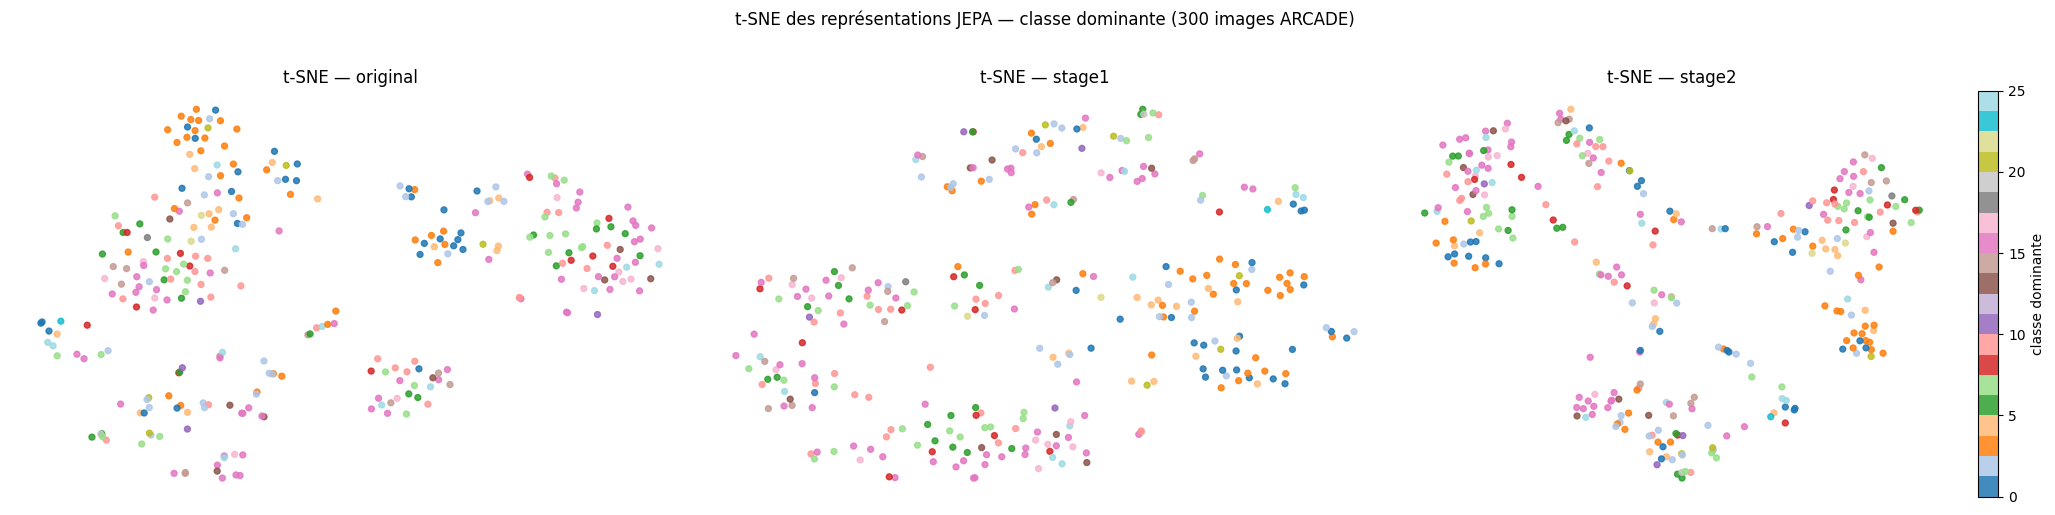

In [21]:
from datasets.arcade_dataset import ArcadeSegDataset
from sklearn.manifold import TSNE
import sklearn
import numpy as np

DATA       = "/home/infres/yrothlin-24/arcade_challenge_datasets"
N_SAMPLES  = 300
BATCH_SIZE = 2

seg_ds = ArcadeSegDataset(
    f"{DATA}/dataset_phase_1/segmentation_dataset/seg_train/images",
    f"{DATA}/dataset_phase_1/segmentation_dataset/seg_train/annotations/seg_train.json",
    img_size=IMG_SIZE,
    augment=False,
)
rng     = np.random.RandomState(42)
indices = rng.choice(len(seg_ds), size=min(N_SAMPLES, len(seg_ds)), replace=False)

images_seg, labels_seg = [], []
for i in indices:
    img, mask = seg_ds[int(i)]
    fg = mask.numpy()[mask.numpy() > 0]
    dominant = int(np.bincount(fg).argmax()) if len(fg) > 0 else 0
    images_seg.append(img * 2 - 1)
    labels_seg.append(dominant)

images_seg = torch.stack(images_seg)
labels_seg = np.array(labels_seg)
print(f"{N_SAMPLES} images — {len(np.unique(labels_seg))} classes présentes")

latents_by_source = {}
for source in SOURCES:
    ae, zs = autoencoders[source], []
    for start in range(0, len(images_seg), BATCH_SIZE):
        batch = images_seg[start:start + BATCH_SIZE].to(device)
        with torch.no_grad():
            zs.append(encode_repr(ae, batch).cpu().flatten(1))
    latents_by_source[source] = torch.cat(zs).numpy()
    print(f"  {source:10s}  repr dim = {latents_by_source[source].shape[1]}")

_sklearn_version = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
_tsne_iter_kw = "max_iter" if _sklearn_version >= (1, 5) else "n_iter"

fig, axes = plt.subplots(1, len(SOURCES), figsize=(7 * len(SOURCES), 5))
for ax, source in zip(axes, SOURCES):
    emb = TSNE(n_components=2, perplexity=30, random_state=42, **{_tsne_iter_kw: 1000}).fit_transform(
        latents_by_source[source]
    )
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels_seg, cmap="tab20",
                    s=18, alpha=0.85, vmin=0, vmax=25)
    ax.set_title(f"t-SNE — {source}")
    ax.axis("off")

plt.colorbar(sc, ax=axes[-1], label="classe dominante")
plt.suptitle(
    f"t-SNE des représentations JEPA — classe dominante ({N_SAMPLES} images ARCADE)",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 6. Classification KNN sur les latents


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

K = 5

cls, counts = np.unique(labels_seg, return_counts=True)
valid_classes = set(cls[counts >= 2])
keep = np.array([l in valid_classes for l in labels_seg])
y    = labels_seg[keep]

rows = []
for source in SOURCES:
    X = latents_by_source[source][keep]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    knn = KNeighborsClassifier(n_neighbors=K, metric="euclidean", n_jobs=-1)
    knn.fit(X_tr, y_tr)
    y_pred = knn.predict(X_te)

    rows.append({
        "source":               source,
        "latent dim":           X.shape[1],
        "n_train":              len(X_tr),
        "n_test":               len(X_te),
        f"KNN-{K} accuracy":   round(accuracy_score(y_te, y_pred), 4),
        "balanced accuracy":   round(balanced_accuracy_score(y_te, y_pred), 4),
    })
    print(f"{source:10s}  acc={rows[-1][f'KNN-{K} accuracy']:.4f}"
          f"  balanced={rows[-1]['balanced accuracy']:.4f}")

df_knn = pd.DataFrame(rows).set_index("source")
df_knn

original    acc=0.1833  balanced=0.1188
stage1      acc=0.2167  balanced=0.1370
stage2      acc=0.1833  balanced=0.1062


,latent dim,n_train,n_test,KNN-5 accuracy,balanced accuracy
source,,,,,
original,16384,236,60,0.1833,0.1188
stage1,4096,236,60,0.2167,0.1370
stage2,4096,236,60,0.1833,0.1062


## 7. Sondage linéaire et rang effectif


/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/infres/yrothlin-24/.local/share/mamba/envs/IM05/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef

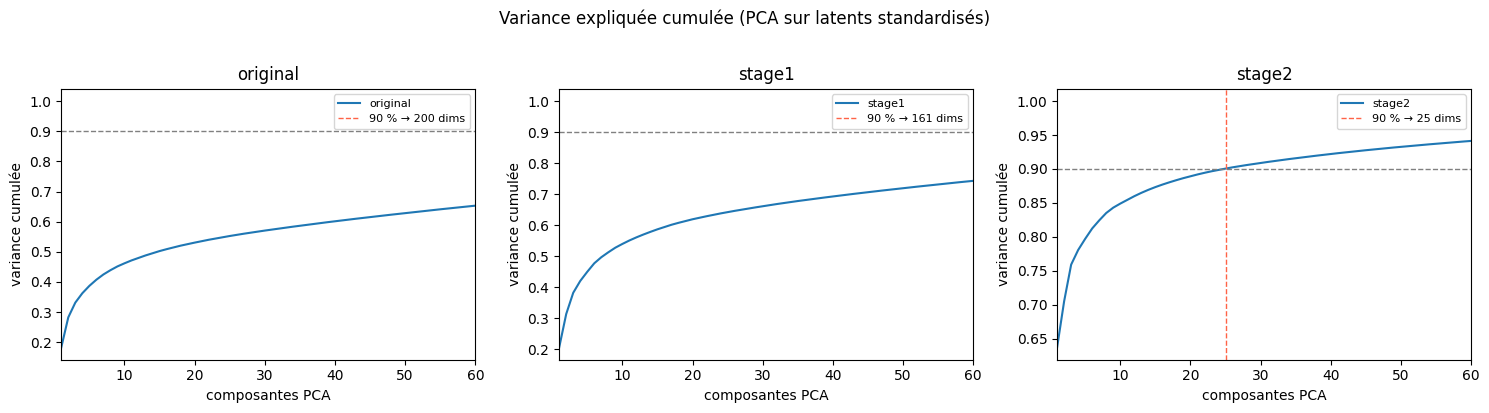

,linear probe acc,balanced lin acc,effective rank,dims @ 90% var,latent dim
source,,,,,
original,0.1500,0.0846,256.6,200,16384
stage1,0.2500,0.1768,239.5,161,4096
stage2,0.2167,0.1546,164.0,25,4096


In [23]:
from sklearn.linear_model import LogisticRegression

rows_lp = []
fig, axes = plt.subplots(1, len(SOURCES), figsize=(5 * len(SOURCES), 4))

for ax, source in zip(axes, SOURCES):
    X = latents_by_source[source][keep]

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=42, stratify=y)

    lr = LogisticRegression(max_iter=500, C=1.0, solver="saga", n_jobs=-1)
    lr.fit(X_tr, y_tr)
    y_pred_lr = lr.predict(X_te)
    lin_acc  = accuracy_score(y_te, y_pred_lr)
    lin_bacc = balanced_accuracy_score(y_te, y_pred_lr)

    _, S, _ = np.linalg.svd(X_s - X_s.mean(0), full_matrices=False)
    S_norm   = S / S.sum()
    eff_rank = float(np.exp(-np.sum(S_norm * np.log(S_norm + 1e-12))))
    cum_var  = np.cumsum(S ** 2) / (S ** 2).sum()
    n90      = int(np.searchsorted(cum_var, 0.90)) + 1

    ax.plot(np.arange(1, len(S) + 1), cum_var, lw=1.5, label=source)
    ax.axhline(0.90, ls="--", c="gray", lw=1)
    ax.axvline(n90, ls="--", c="tomato", lw=1, label=f"90 % → {n90} dims")
    ax.set_title(source)
    ax.set_xlabel("composantes PCA")
    ax.set_ylabel("variance cumulée")
    ax.set_xlim(1, min(60, len(S)))
    ax.legend(fontsize=8)

    rows_lp.append({
        "source":              source,
        "linear probe acc":    round(lin_acc,  4),
        "balanced lin acc":    round(lin_bacc, 4),
        "effective rank":      round(eff_rank, 1),
        "dims @ 90% var":      n90,
        "latent dim":          X.shape[1],
    })

plt.suptitle("Variance expliquée cumulée (PCA sur latents standardisés)", y=1.02)
plt.tight_layout()
plt.show()

df_lp = pd.DataFrame(rows_lp).set_index("source")
df_lp

## 8. Qualité de reconstruction à l'échelle — PSNR sur 100 images


In [24]:
import math

N_RECON      = min(len(val_ds), 100)
recon_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

rows_recon = []
for source, ae in autoencoders.items():
    sum_mse, sum_mae, n = 0.0, 0.0, 0
    with torch.no_grad():
        for batch in recon_loader:
            if n >= N_RECON:
                break
            batch  = batch[:N_RECON - n].to(device)
            recon  = ae.decode(ae.encode(batch).mode()).clamp(-1, 1)
            diff   = recon - batch
            sum_mse += float((diff ** 2).sum())
            sum_mae += float(diff.abs().sum())
            n += batch.shape[0]

    npix   = n * IMG_SIZE * IMG_SIZE
    mse    = sum_mse / npix
    mae    = sum_mae / npix
    psnr   = 10 * math.log10(4.0 / mse)

    rows_recon.append({
        "source":     source,
        "n images":   n,
        "MSE":        round(mse,  5),
        "MAE":        round(mae,  4),
        "PSNR (dB)":  round(psnr, 2),
    })
    print(f"{source:10s}  MSE={mse:.5f}  MAE={mae:.4f}  PSNR={psnr:.2f} dB")

pd.DataFrame(rows_recon).set_index("source")

original    MSE=0.00223  MAE=0.0326  PSNR=32.54 dB
stage1      MSE=0.00332  MAE=0.0414  PSNR=30.81 dB
stage2      MSE=0.08268  MAE=0.2295  PSNR=16.85 dB


,n images,MSE,MAE,PSNR (dB)
source,,,,
original,100,0.00223,0.0326,32.54
stage1,100,0.00332,0.0414,30.81
stage2,100,0.08268,0.2295,16.85


## 9. Traversée des axes PCA dans l'espace latent


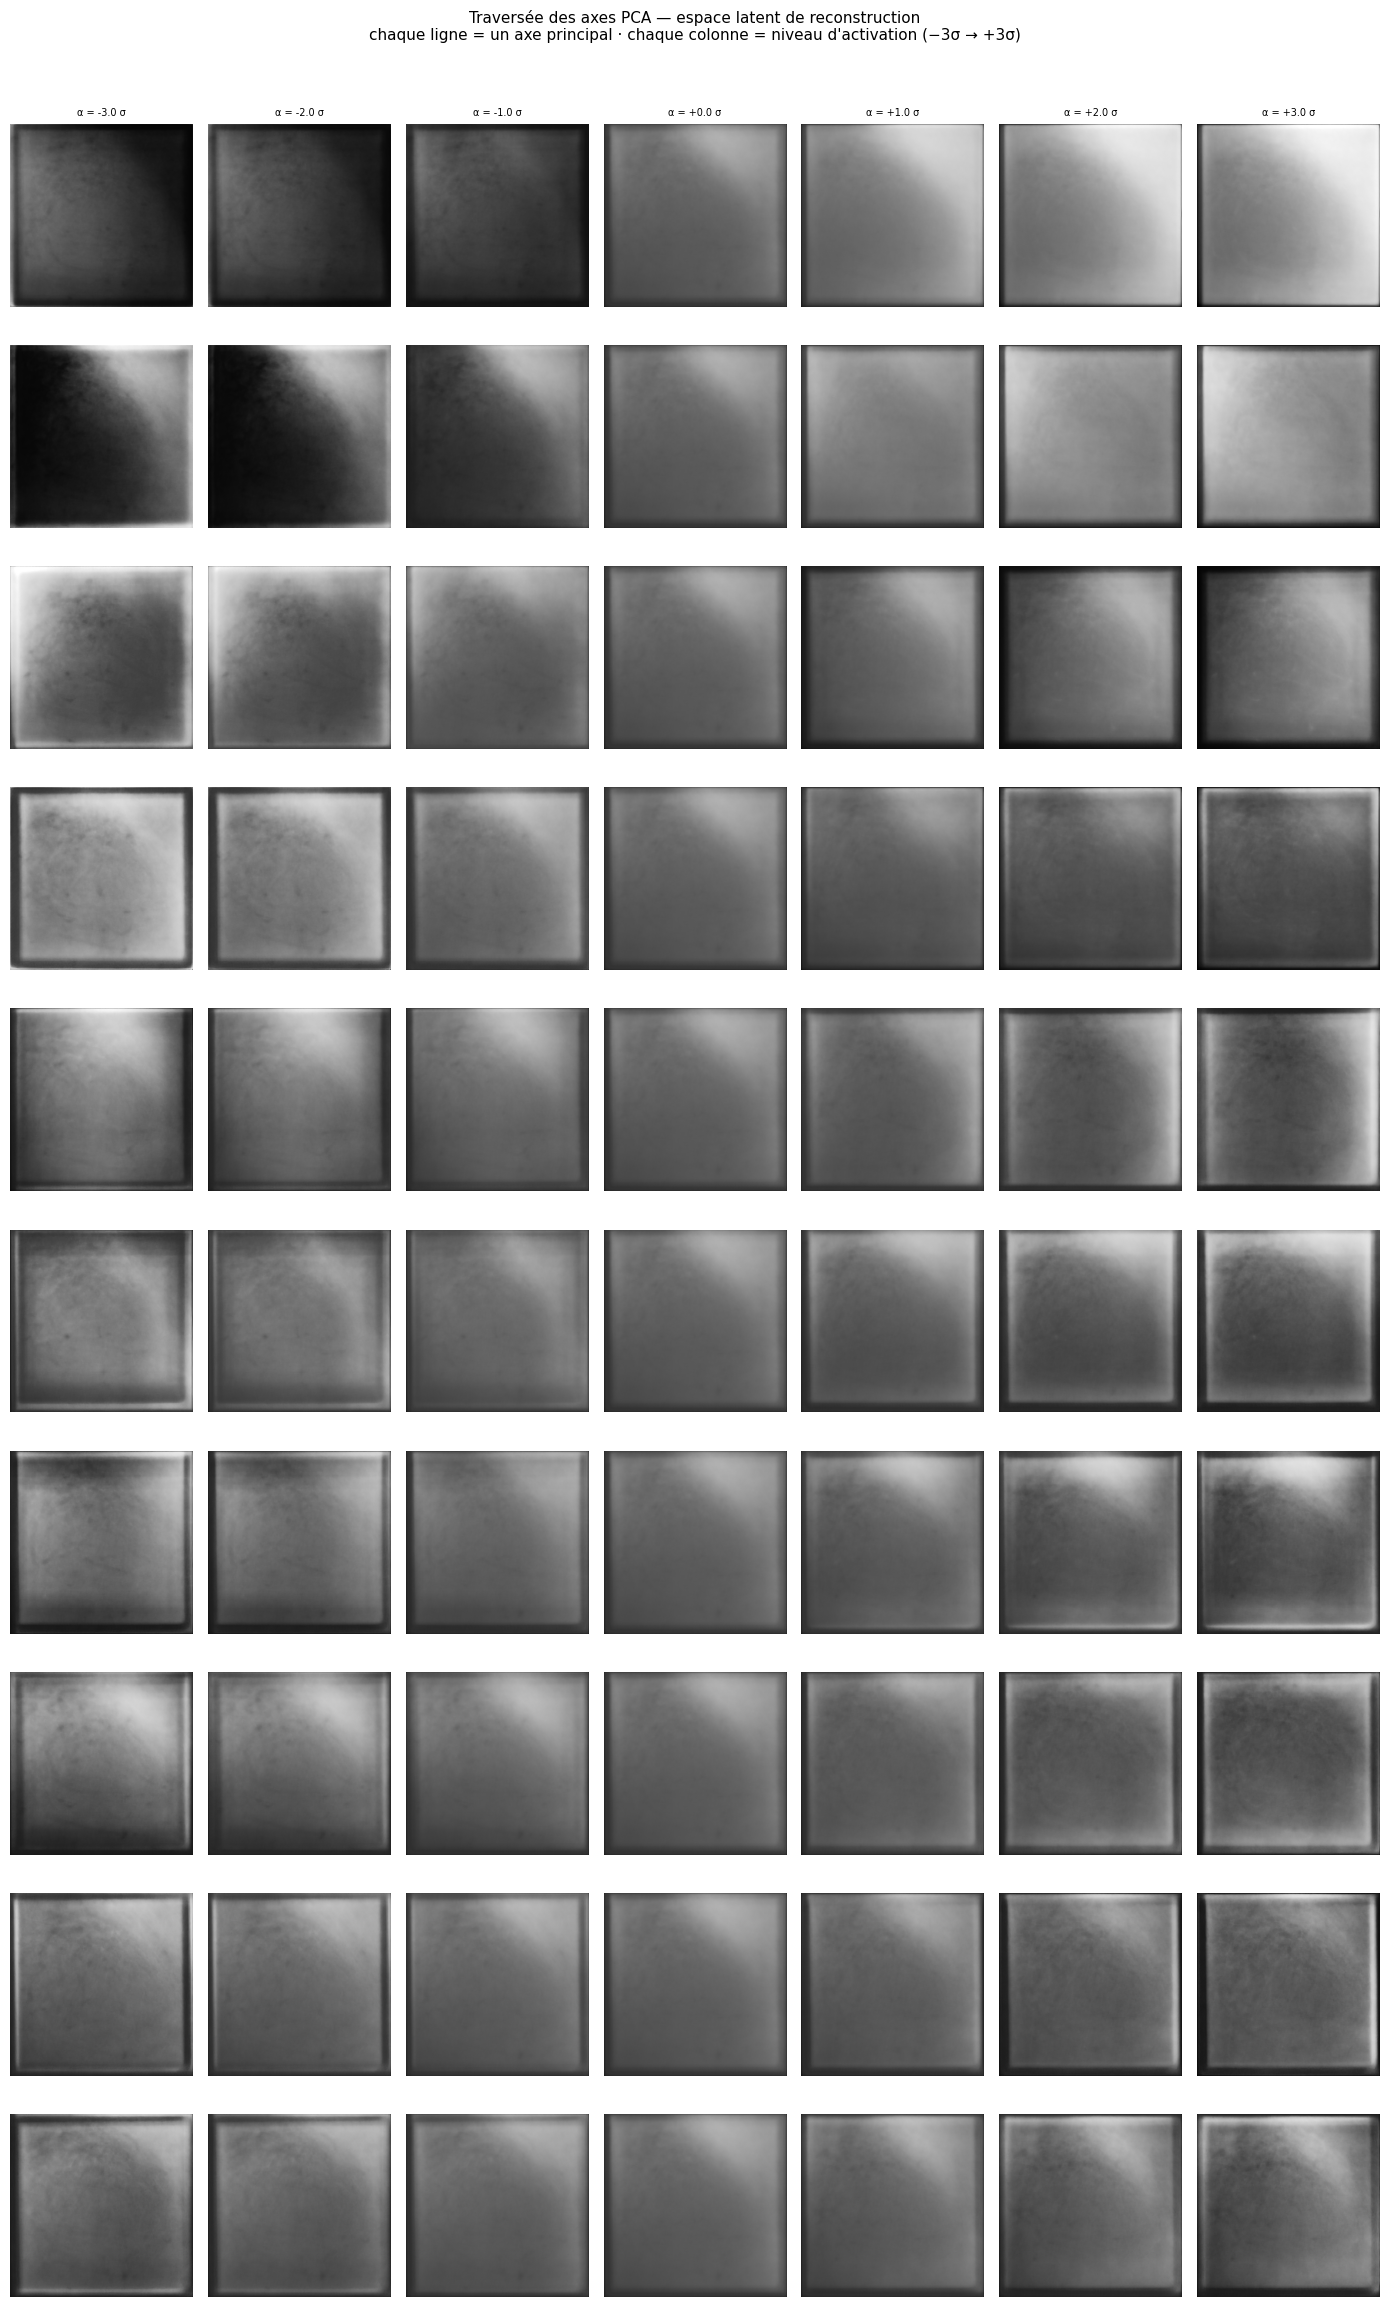

In [25]:
from sklearn.decomposition import PCA

N_TRAVERSE = 7
N_PC       = 10
alphas     = np.linspace(-3, 3, N_TRAVERSE)
SOURCES = ["original"]


fig, axes = plt.subplots(
    len(SOURCES) * N_PC, N_TRAVERSE,
    figsize=(2 * N_TRAVERSE, 2.3 * len(SOURCES) * N_PC),
)

for src_idx, source in enumerate(SOURCES):
    ae = autoencoders[source]

    recon_zs = []
    for start in range(0, len(images_seg), BATCH_SIZE):
        batch = images_seg[start : start + BATCH_SIZE].to(device)
        with torch.no_grad():
            recon_zs.append(ae.encode(batch).mode().cpu())
    Z_recon = torch.cat(recon_zs)
    Z_flat  = Z_recon.flatten(1).numpy()

    z_mean = Z_flat.mean(0)
    pca    = PCA(n_components=N_PC)
    pca.fit(Z_flat - z_mean)

    z_mean_t = torch.tensor(z_mean, dtype=torch.float32)
    C, H, W  = tuple(Z_recon.shape[1:])

    for pc_idx in range(N_PC):
        pc        = torch.tensor(pca.components_[pc_idx], dtype=torch.float32)
        std       = float(np.sqrt(pca.explained_variance_[pc_idx]))
        var_ratio = pca.explained_variance_ratio_[pc_idx]

        for t_idx, alpha in enumerate(alphas):
            ax = axes[src_idx * N_PC + pc_idx, t_idx]

            z_perturb = (z_mean_t + alpha * std * pc).reshape(1, C, H, W).to(device)
            with torch.no_grad():
                img = ae.decode(z_perturb).squeeze().cpu().clamp(-1, 1).numpy()

            ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
            ax.axis("off")

            if t_idx == 0:
                ax.set_ylabel(
                    f"{source}\nPC{pc_idx + 1} ({var_ratio:.1%})",
                    fontsize=8, rotation=0, labelpad=60, va="center",
                )
            if src_idx == 0 and pc_idx == 0:
                ax.set_title(f"α = {alpha:+.1f} σ", fontsize=7)

plt.suptitle(
    "Traversée des axes PCA — espace latent de reconstruction\n"
    "chaque ligne = un axe principal · chaque colonne = niveau d'activation (−3σ → +3σ)",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 10. Visualisation PCA des features encodeur (style LeJEPA / DINO)


  original    feat shape: (512, 128, 128)
  stage1      feat shape: (256, 64, 64)
  stage2      feat shape: (256, 64, 64)


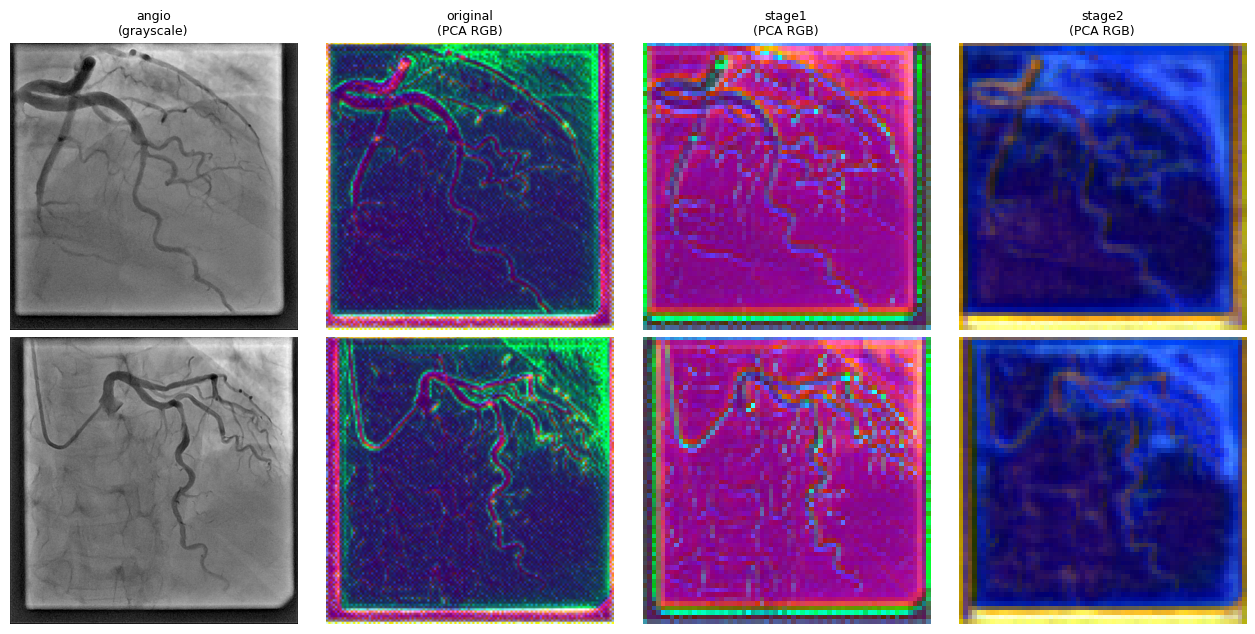

In [35]:
from sklearn.decomposition import PCA

N_PCA  = 50
N_SHOW = 2

def extract_penultimate(ae, images, batch_size=2):
    """
    Feature maps juste avant conv_out de l'encodeur (après norm_out + nonlinearity).
    Shape retournée : (N, C, H, W)  où C = ch * ch_mult[-1]
    """
    feats = []

    def _hook(m, inp):
        feats.append(inp[0].detach().cpu())

    handle = ae.encoder.conv_out.register_forward_pre_hook(_hook)
    try:
        for start in range(0, len(images), batch_size):
            batch = images[start : start + batch_size].to(device)
            with torch.no_grad():
                _ = ae.encode(batch)
    finally:
        handle.remove()
    return torch.cat(feats)


def pca_rgb(feat_fit, feat_apply):
    """Projette les features sur les 3 premières composantes PCA → RGB [0, 1]."""
    N, C, H, W = feat_apply.shape
    flat_fit   = feat_fit.permute(0, 2, 3, 1).reshape(-1, C).numpy()
    flat_apply = feat_apply.permute(0, 2, 3, 1).reshape(-1, C).numpy()
    pca  = PCA(n_components=3)
    pca.fit(flat_fit)
    proj = pca.transform(flat_apply)
    for c in range(3):
        lo, hi = np.percentile(proj[:, c], 2), np.percentile(proj[:, c], 98)
        proj[:, c] = np.clip((proj[:, c] - lo) / (hi - lo + 1e-8), 0, 1)
    return proj.reshape(N, H, W, 3)


imgs_fit  = images_seg[:N_PCA]
imgs_show = images_seg[:N_SHOW]

rgb_by_source = {}
for source in ["original", "stage1", "stage2"]:
    ae = autoencoders[source]
    F_fit   = extract_penultimate(ae, imgs_fit)
    F_show  = extract_penultimate(ae, imgs_show)
    rgb_by_source[source] = pca_rgb(F_fit, F_show)
    print(f"  {source:10s}  feat shape: {tuple(F_fit.shape[1:])}")

ncols = 1 + 3
fig, axes = plt.subplots(N_SHOW, ncols, figsize=(3.2 * ncols, 3.2 * N_SHOW))

for img_idx in range(N_SHOW):
    axes[img_idx, 0].imshow(imgs_show[img_idx, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
    axes[img_idx, 0].axis("off")
    if img_idx == 0:
        axes[img_idx, 0].set_title("angio\n(grayscale)", fontsize=9)
    axes[img_idx, 0].set_ylabel(f"img #{img_idx}", fontsize=8, rotation=0, labelpad=40, va="center")

    for src_idx, source in enumerate(["original", "stage1", "stage2"]):
        ax = axes[img_idx, src_idx + 1]
        ax.imshow(rgb_by_source[source][img_idx])
        ax.axis("off")
        if img_idx == 0:
            ax.set_title(f"{source}\n(PCA RGB)", fontsize=9)

plt.tight_layout()
plt.show()

## 11. Segmentation non supervisée des features (k-means)


/tmp/ipykernel_45391/3549409949.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)
/tmp/ipykernel_45391/3549409949.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)
/tmp/ipykernel_45391/3549409949.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)


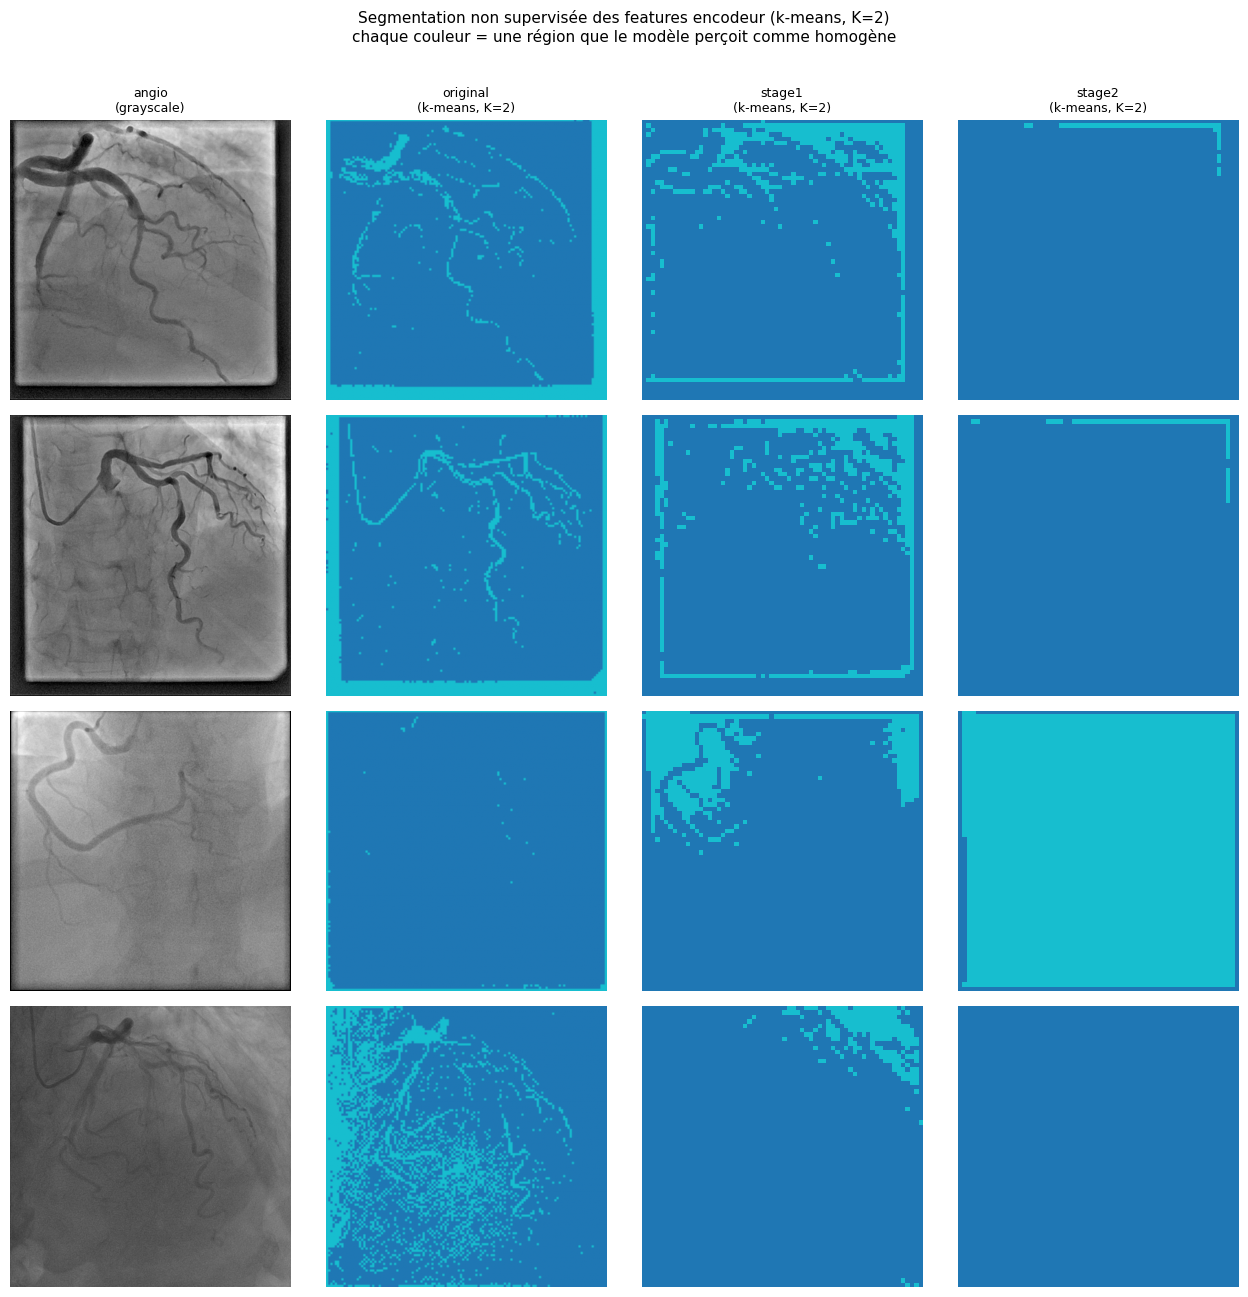

In [27]:
from sklearn.cluster import MiniBatchKMeans

K = 2

def feature_kmeans(feat_fit, feat_apply, k=8, seed=42):
    """
    K-means sur les feature vectors → carte de labels → image RGB.
    feat_fit   : (N_fit, C, H, W)  — pour fitter le k-means
    feat_apply : (N,     C, H, W)  — pour prédire les labels
    Retourne   : (N, H, W, 3) float [0, 1]
    """
    N, C, H, W = feat_apply.shape
    flat_fit   = feat_fit.permute(0, 2, 3, 1).reshape(-1, C).numpy()
    flat_apply = feat_apply.permute(0, 2, 3, 1).reshape(-1, C).numpy()

    km = MiniBatchKMeans(n_clusters=k, random_state=seed, n_init=5)
    km.fit(flat_fit)
    labels = km.predict(flat_apply).reshape(N, H, W)

    cmap = plt.cm.get_cmap("tab10", k)
    return cmap(labels / k)[..., :3]


kmeans_by_source = {}
for source in ["original", "stage1", "stage2"]:
    ae = autoencoders[source]
    F_fit  = extract_penultimate(ae, imgs_fit)
    F_show = extract_penultimate(ae, imgs_show)
    kmeans_by_source[source] = feature_kmeans(F_fit, F_show, k=K)

ncols = 1 + 3
fig, axes = plt.subplots(N_SHOW, ncols, figsize=(3.2 * ncols, 3.2 * N_SHOW))

for img_idx in range(N_SHOW):
    axes[img_idx, 0].imshow(imgs_show[img_idx, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
    axes[img_idx, 0].axis("off")
    if img_idx == 0:
        axes[img_idx, 0].set_title("angio\n(grayscale)", fontsize=9)
    axes[img_idx, 0].set_ylabel(f"img #{img_idx}", fontsize=8, rotation=0, labelpad=40, va="center")

    for src_idx, source in enumerate(["original", "stage1", "stage2"]):
        ax = axes[img_idx, src_idx + 1]
        ax.imshow(kmeans_by_source[source][img_idx])
        ax.axis("off")
        if img_idx == 0:
            ax.set_title(f"{source}\n(k-means, K={K})", fontsize=9)

plt.suptitle(
    f"Segmentation non supervisée des features encodeur (k-means, K={K})\n"
    "chaque couleur = une région que le modèle perçoit comme homogène",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.show()

## 12. MedSAM — chargement


In [29]:
from transformers import SamModel, SamProcessor
from PIL import Image as PILImage

MEDSAM_REPO = "flaviagiammarino/medsam-vit-base"
HF_CACHE    = "/home/infres/yrothlin-24/.cache/huggingface"

medsam           = SamModel.from_pretrained(MEDSAM_REPO, cache_dir=HF_CACHE).to(device).eval()
medsam_processor = SamProcessor.from_pretrained(MEDSAM_REPO, cache_dir=HF_CACHE)

print(f"MedSAM chargé — paramètres image encoder : "
      f"{sum(p.numel() for p in medsam.vision_encoder.parameters()) / 1e6:.1f} M")


def encode_medsam(images_tensor, batch_size=2):
    """
    images_tensor : (N, 1, H, W) dans [-1, 1]
    Retourne      : (N, 256, 64, 64) — image embeddings MedSAM (après neck ViT-B)
    """
    embeddings = []
    for start in range(0, len(images_tensor), batch_size):
        batch = images_tensor[start : start + batch_size]
        pil_imgs = []
        for img in batch:
            arr = ((img[0].numpy() + 1.0) / 2.0 * 255.0).clip(0, 255).astype(np.uint8)
            pil_imgs.append(PILImage.fromarray(np.stack([arr] * 3, axis=-1)))

        inputs = medsam_processor(images=pil_imgs, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(device)
        with torch.no_grad():
            emb = medsam.get_image_embeddings(pixel_values)
        embeddings.append(emb.cpu())
    return torch.cat(embeddings)


_test = encode_medsam(images_seg[:2])
print(f"Forme des embeddings MedSAM : {tuple(_test.shape)}")

Loading weights: 100%|██████████| 315/315 [00:00<00:00, 56711.41it/s]


MedSAM chargé — paramètres image encoder : 89.7 M
Forme des embeddings MedSAM : (2, 256, 64, 64)


## 13. Comparaison MedSAM — features visuelles (PCA RGB + k-means)


  original    feat shape: (512, 128, 128)
  stage1      feat shape: (256, 64, 64)
  stage2      feat shape: (256, 64, 64)
  medsam      feat shape: (256, 64, 64)


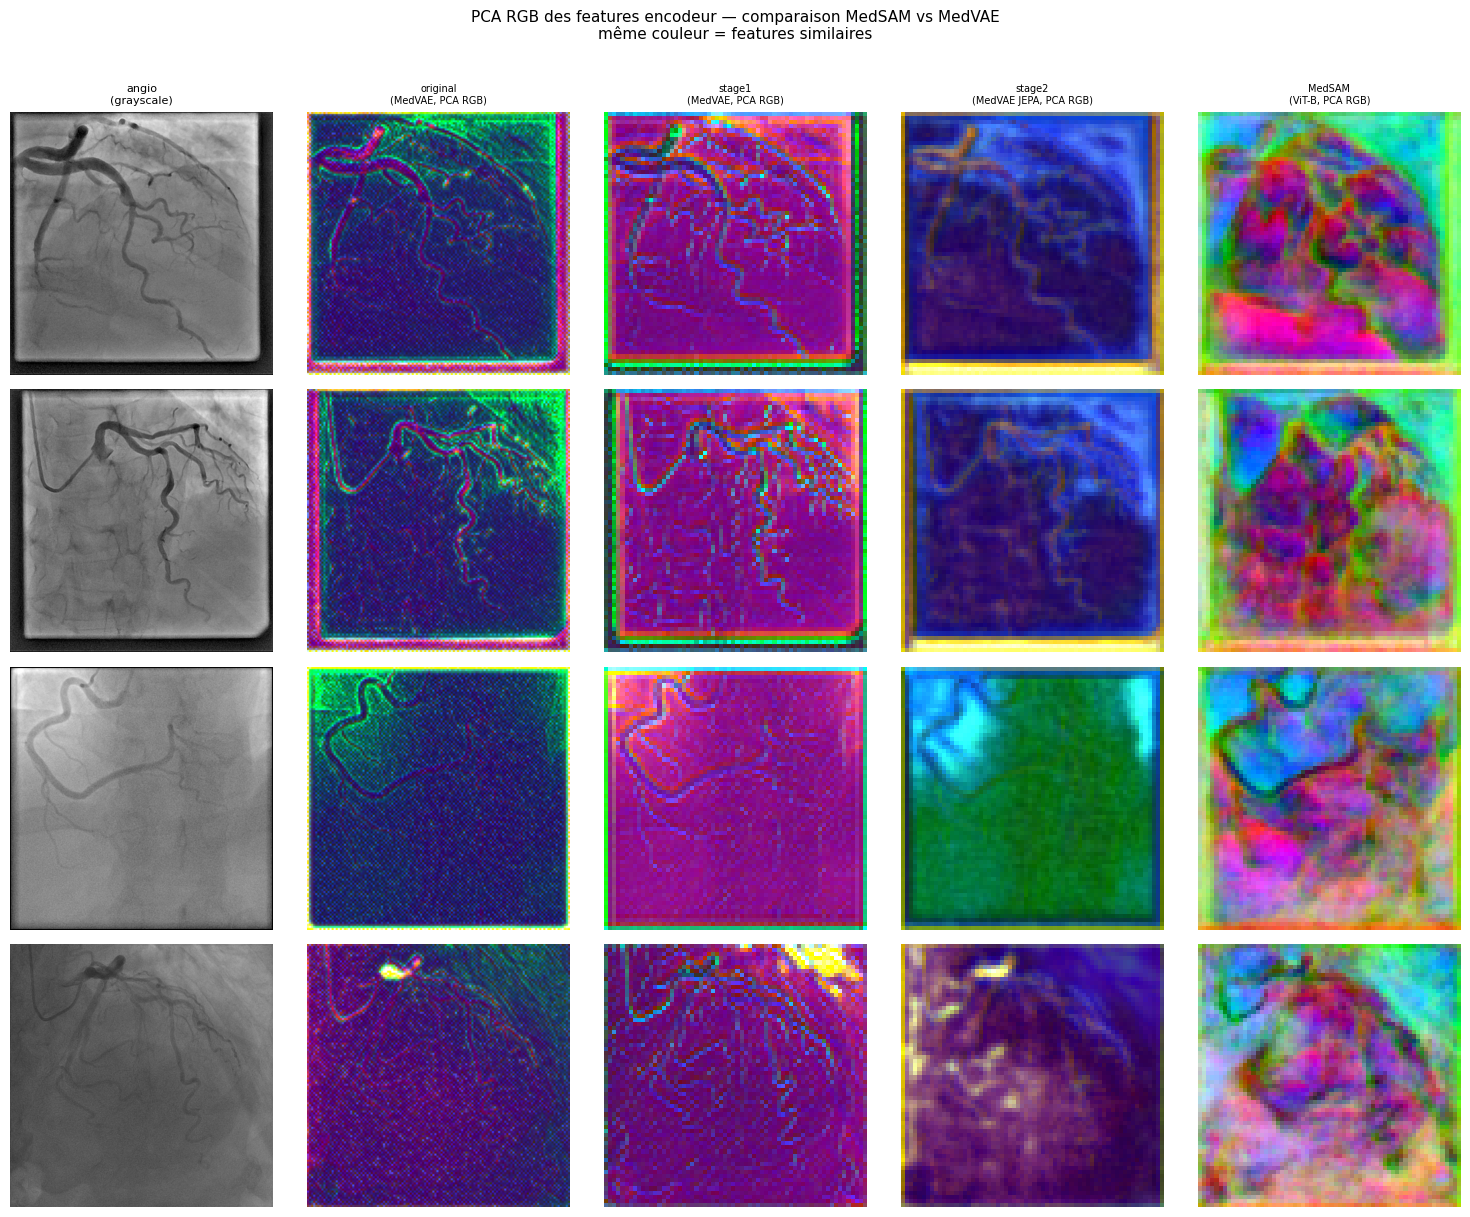

/tmp/ipykernel_45391/1210278783.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)
/tmp/ipykernel_45391/1210278783.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)
/tmp/ipykernel_45391/1210278783.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", k)
/tmp/ipykernel_45391/1210278783.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated 

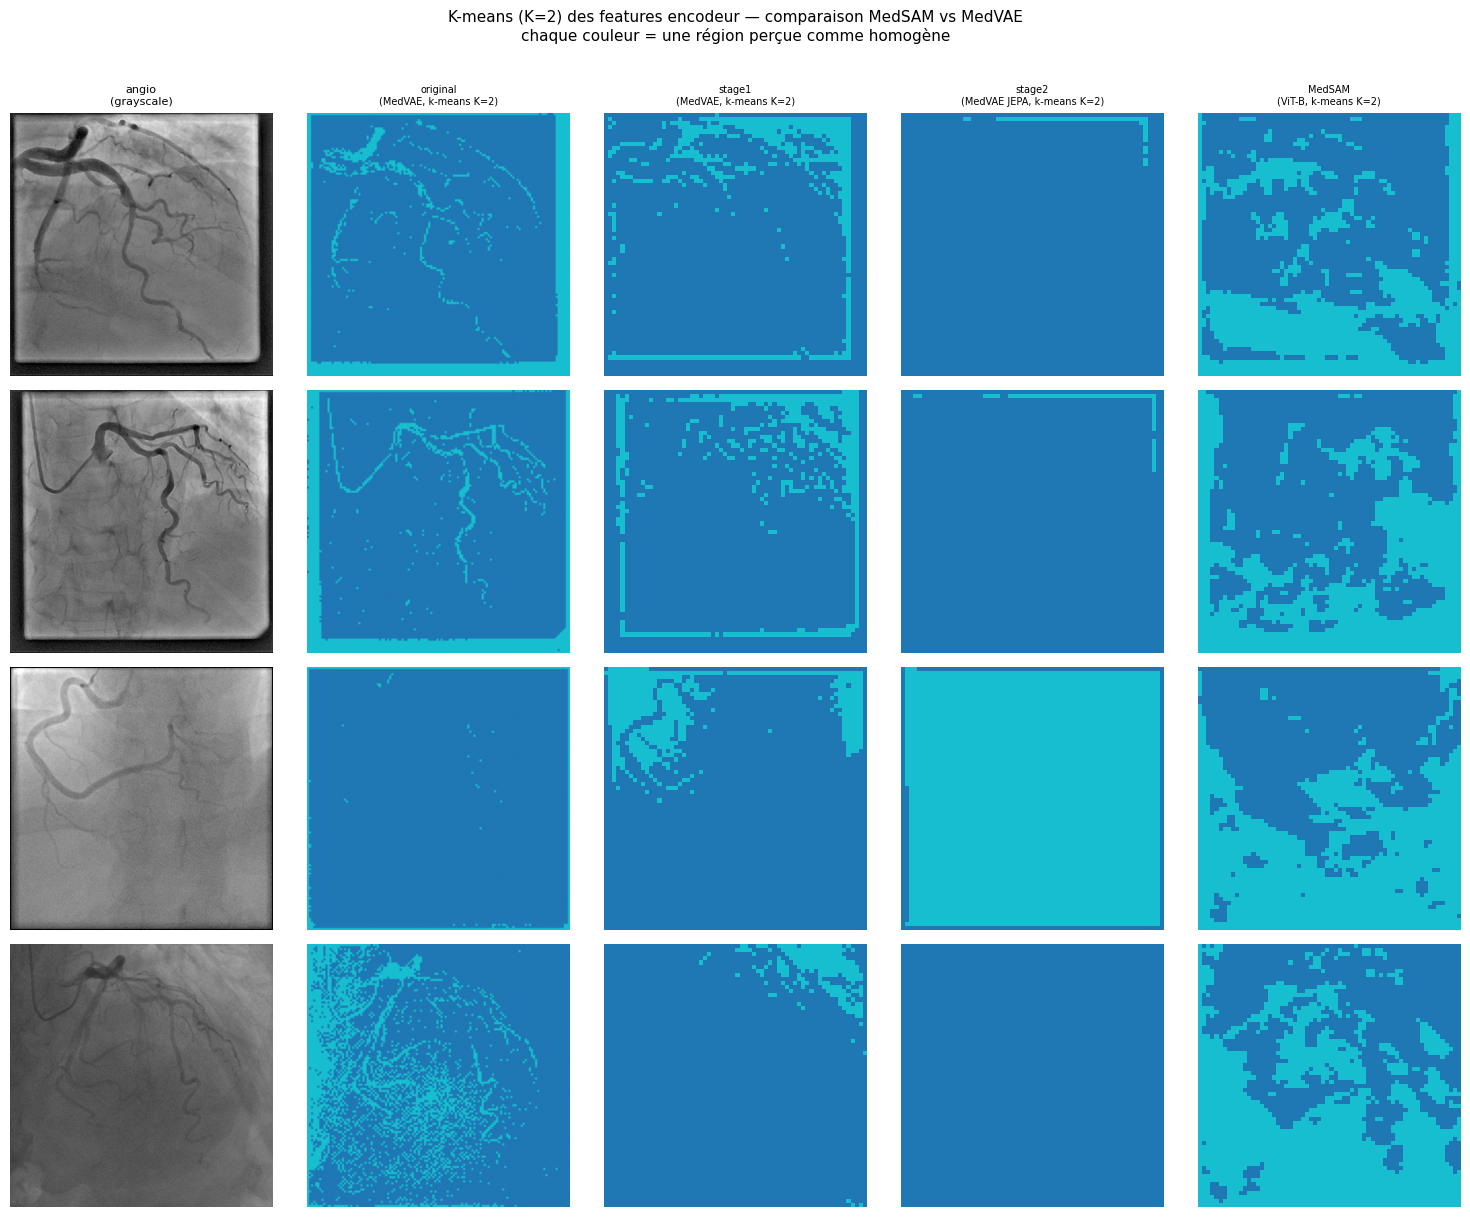

In [30]:
ALL_SOURCES = ["original", "stage1", "stage2", "medsam"]

feat_fit_all  = {}
feat_show_all = {}

for source in ALL_SOURCES:
    if source == "medsam":
        feat_fit_all[source]  = encode_medsam(imgs_fit)
        feat_show_all[source] = encode_medsam(imgs_show)
    else:
        ae = autoencoders[source]
        feat_fit_all[source]  = extract_penultimate(ae, imgs_fit)
        feat_show_all[source] = extract_penultimate(ae, imgs_show)
    print(f"  {source:10s}  feat shape: {tuple(feat_fit_all[source].shape[1:])}")

rgb_all = {s: pca_rgb(feat_fit_all[s], feat_show_all[s]) for s in ALL_SOURCES}

ncols = 1 + len(ALL_SOURCES)
fig, axes = plt.subplots(N_SHOW, ncols, figsize=(3.0 * ncols, 3.0 * N_SHOW))

titles = {"original": "original\n(MedVAE, PCA RGB)",
          "stage1":   "stage1\n(MedVAE, PCA RGB)",
          "stage2":   "stage2\n(MedVAE JEPA, PCA RGB)",
          "medsam":   "MedSAM\n(ViT-B, PCA RGB)"}

for img_idx in range(N_SHOW):
    axes[img_idx, 0].imshow(imgs_show[img_idx, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
    axes[img_idx, 0].axis("off")
    axes[img_idx, 0].set_ylabel(f"img #{img_idx}", fontsize=8, rotation=0, labelpad=40, va="center")
    if img_idx == 0:
        axes[img_idx, 0].set_title("angio\n(grayscale)", fontsize=8)
    for col, source in enumerate(ALL_SOURCES, 1):
        ax = axes[img_idx, col]
        ax.imshow(rgb_all[source][img_idx])
        ax.axis("off")
        if img_idx == 0:
            ax.set_title(titles[source], fontsize=7)

plt.suptitle("PCA RGB des features encodeur — comparaison MedSAM vs MedVAE\n"
             "même couleur = features similaires", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

km_all = {s: feature_kmeans(feat_fit_all[s], feat_show_all[s], k=2) for s in ALL_SOURCES}

titles_km = {s: t.replace("PCA RGB", "k-means K=2") for s, t in titles.items()}

fig, axes = plt.subplots(N_SHOW, ncols, figsize=(3.0 * ncols, 3.0 * N_SHOW))
for img_idx in range(N_SHOW):
    axes[img_idx, 0].imshow(imgs_show[img_idx, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
    axes[img_idx, 0].axis("off")
    axes[img_idx, 0].set_ylabel(f"img #{img_idx}", fontsize=8, rotation=0, labelpad=40, va="center")
    if img_idx == 0:
        axes[img_idx, 0].set_title("angio\n(grayscale)", fontsize=8)
    for col, source in enumerate(ALL_SOURCES, 1):
        ax = axes[img_idx, col]
        ax.imshow(km_all[source][img_idx])
        ax.axis("off")
        if img_idx == 0:
            ax.set_title(titles_km[source], fontsize=7)

plt.suptitle("K-means (K=2) des features encodeur — comparaison MedSAM vs MedVAE\n"
             "chaque couleur = une région perçue comme homogène", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

## 14. Comparaison MedSAM — structure de l'espace latent (KNN + sondage linéaire)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler

feat_all_300 = {}
for source in ALL_SOURCES:
    if source == "medsam":
        feat_all_300[source] = encode_medsam(images_seg)
    else:
        feat_all_300[source] = extract_penultimate(autoencoders[source], images_seg)
    print(f"  {source:10s}  shape: {tuple(feat_all_300[source].shape)}")

def gap(feat):
    return feat.mean(dim=(2, 3)).numpy()

y = labels_seg[keep]

rows_cmp = []
for source in ALL_SOURCES:
    X = gap(feat_all_300[source])[keep]
    scaler   = StandardScaler()
    X_s      = scaler.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=42, stratify=y)

    knn    = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn.fit(X_tr, y_tr)
    knn_acc  = accuracy_score(y_te, knn.predict(X_te))
    knn_bacc = balanced_accuracy_score(y_te, knn.predict(X_te))

    lr = LogisticRegression(max_iter=500, C=1.0, solver="saga")
    lr.fit(X_tr, y_tr)
    lin_acc  = accuracy_score(y_te, lr.predict(X_te))
    lin_bacc = balanced_accuracy_score(y_te, lr.predict(X_te))

    rows_cmp.append({
        "source":             source,
        "KNN-5 acc":          round(knn_acc,  4),
        "KNN-5 balanced":     round(knn_bacc, 4),
        "linear probe acc":   round(lin_acc,  4),
        "linear balanced":    round(lin_bacc, 4),
    })
    print(f"{source:10s}  KNN={knn_acc:.4f}  lin={lin_acc:.4f}")

df_cmp = pd.DataFrame(rows_cmp).set_index("source")
df_cmp